In [31]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, average_precision_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from src.data import get_data, split_data
from src.features import clean_data, prepare_data, clean_data_xgb

import xgboost as xgb

In [2]:
df = get_data()
df_train, df_val, df_test, df_full_train = split_data(df)
df_train, medians = clean_data(df_train, fit=True)
df_val, _ = clean_data(df_val, fit=False, medians=medians)
df_test, _ = clean_data(df_test, fit=False, medians=medians)
X_train, y_train, encoder, scaler, features_train = prepare_data(df_train, fit=True)
X_val, y_val, _, _,features_val = prepare_data(df_val, encoder=encoder, scaler=scaler)
X_test, y_test, _, _, features_test = prepare_data(df_test, encoder=encoder, scaler=scaler)


In [115]:
joblib.dump(encoder, '../models/final_encoder.pkl')
joblib.dump(scaler, '../models/final_scaler.pkl')

['../models/final_scaler.pkl']

# Logistic Regression

In [5]:
# Properly separated param grid so l1_ratio ONLY applies to elasticnet
param_grid = [
    # Grid 1: liblinear (Fast, L1 & L2)
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-3, 3, 15)
    },
    # Grid 2: SAGA (L1 & L2 only)
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-3, 3, 15)
    },
    # Grid 3: SAGA (ElasticNet only - l1_ratio applied exclusively here)
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': np.logspace(-3, 3, 10),
        'l1_ratio': [0.2, 0.5, 0.8]
    },
    # Grid 4: LBFGS (L2 & None)
    {
        'solver': ['lbfgs'],
        'penalty': ['l2', None],
        'C': np.logspace(-3, 3, 15)
    }
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=3000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\samis\loan-default-prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': array([1.0000...00000000e+03]), 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, {'C': array([1.0000...00000000e+03]), 'penalty': ['l1', 'l2'], 'solver': ['saga']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more ab

In [6]:
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best 5-Fold CV ROC-AUC: {grid_search.best_score_:.5f}")

Best Hyperparameters: {'C': np.float64(0.13894954943731375), 'penalty': 'l2', 'solver': 'lbfgs'}
Best 5-Fold CV ROC-AUC: 0.78662


In [ ]:
joblib.dump(grid_search.best_estimator_, '../models/final_logreg_model.pkl')

In [3]:
final_logreg_model = joblib.load('../models/final_logreg_model.pkl')

In [80]:
y_val_pred_logreg = final_logreg_model.predict_proba(X_val)[:, 1]
roc_auc_logreg = roc_auc_score(y_val, y_val_pred_logreg)
roc_auc_logreg

0.789556987875641

In [81]:
pr_auc_logreg = average_precision_score(y_val, y_val_pred_logreg)
pr_auc_logreg

0.6829024101393125

In [ ]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []

for t in thresholds:
    y_bin = (y_val_pred_logreg >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics_logreg = pd.DataFrame(rows)

# Decision Tree

In [6]:
model = DecisionTreeClassifier(random_state=42)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

param_grid = {
    'ccp_alpha': ccp_alphas[::10]
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 378 candidates, totalling 1890 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ccp_alpha': array([0.0000...94385162e-02])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFo

In [7]:
print(f'Best alpha value: {grid_search.best_params_['ccp_alpha']}')
print(f"Best 5-Fold CV ROC-AUC: {grid_search.best_score_:.5f}")

Best alpha value: 6.371325946783997e-05
Best 5-Fold CV ROC-AUC: 0.87463


In [8]:
joblib.dump(grid_search.best_estimator_, '../models/final_dt_model.pkl')

['../models/final_dt_model.pkl']

In [9]:
final_dt_model = joblib.load('../models/final_dt_model.pkl')

In [82]:
y_val_pred_dt = final_dt_model.predict_proba(X_val)[:, 1]
roc_auc_dt = roc_auc_score(y_val, y_val_pred_dt)
roc_auc_dt

0.8765954730504808

In [83]:
pr_auc_dt = average_precision_score(y_val, y_val_pred_dt)
pr_auc_dt

0.812156672356435

In [ ]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []

for t in thresholds:
    y_bin = (y_val_pred_dt >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics_dt = pd.DataFrame(rows)

# Random Forest

In [14]:
param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [5, 10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

rand_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    random_state=42,
    n_iter=50,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

rand_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to ba

In [17]:
print(f'Best alpha value: {rand_search.best_params_}')
print(f"Best 5-Fold CV ROC-AUC: {rand_search.best_score_:.5f}")

Best alpha value: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Best 5-Fold CV ROC-AUC: 0.88856


In [18]:
joblib.dump(rand_search.best_estimator_, '../models/final_rf_model.pkl')

['../models/final_rf_model.pkl']

In [19]:
final_rf_model = joblib.load('../models/final_rf_model.pkl')

In [84]:
y_val_pred_rf = final_rf_model.predict_proba(X_val)[:, 1]
roc_auc_rf = roc_auc_score(y_val, y_val_pred_rf)
roc_auc_rf

0.8896385425771707

In [85]:
pr_auc_rf = average_precision_score(y_val, y_val_pred_rf)
pr_auc_rf

0.8294677256314751

In [ ]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []

for t in thresholds:
    y_bin = (y_val_pred_rf >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics_rf = pd.DataFrame(rows)

# XGBoost

In [22]:
neg, pos = np.bincount(y_train)
ratio = neg / pos

param_distributions = {
    "scale_pos_weight": [1, ratio * 0.5, ratio, ratio * 1.5, ratio * 2],
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5, 1, 2],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [0.5, 1, 2, 5, 10]
}

rand_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        eval_metric='auc',
        n_jobs=1
    ),
    param_distributions=param_distributions,
    random_state=42,
    verbose=2,
    n_jobs=-1,
    scoring='roc_auc',
    n_iter=100
)

rand_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance m

In [23]:
print(f'Best hyperparameters: {rand_search.best_params_}')
print(f'Best score: {rand_search.best_score_}')

Best hyperparameters: {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Best score: 0.8932941262990454


In [24]:
joblib.dump(rand_search.best_estimator_, '../models/final_xgb_model.pkl')

['../models/final_xgb_model.pkl']

In [25]:
final_xgb_model = joblib.load('../models/final_xgb_model.pkl')

In [86]:
y_val_pred_xgb = final_xgb_model.predict_proba(X_val)[:, 1]
roc_auc_xgb = roc_auc_score(y_val, y_val_pred_xgb)
roc_auc_xgb

0.8929239921160688

In [87]:
pr_auc_xgb = average_precision_score(y_val, y_val_pred_xgb)
pr_auc_xgb

0.8372344499132592

In [ ]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []

for t in thresholds:
    y_bin = (y_val_pred_xgb >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics_xgb = pd.DataFrame(rows)

In [68]:
target_recall = np.linspace(0.50, 0.91, 41)
for t in target_recall:
    for name, df in [('logreg', df_metrics_logreg), ('tree', df_metrics_dt), ('rf', df_metrics_rf), ('xgb', df_metrics_xgb)]:
            candidates = df[df['recall'] >= t]
            if len(candidates):
                best_row = candidates.loc[candidates['precision'].idxmax()]
                print(f"{name}: threshold={best_row['threshold']:.2f}, precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}")
            else:
                print(f"{name}: never reaches {t} recall")
    print()

logreg: threshold=0.42, precision=0.729, recall=0.503
tree: threshold=0.88, precision=0.986, recall=0.508
rf: threshold=0.66, precision=0.979, recall=0.501
xgb: threshold=0.81, precision=0.993, recall=0.503

logreg: threshold=0.40, precision=0.712, recall=0.514
tree: threshold=0.87, precision=0.984, recall=0.512
rf: threshold=0.64, precision=0.974, recall=0.513
xgb: threshold=0.78, precision=0.991, recall=0.514

logreg: threshold=0.38, precision=0.689, recall=0.524
tree: threshold=0.84, precision=0.978, recall=0.522
rf: threshold=0.62, precision=0.968, recall=0.524
xgb: threshold=0.75, precision=0.986, recall=0.525

logreg: threshold=0.36, precision=0.666, recall=0.535
tree: threshold=0.73, precision=0.965, recall=0.533
rf: threshold=0.60, precision=0.961, recall=0.533
xgb: threshold=0.73, precision=0.982, recall=0.536

logreg: threshold=0.35, precision=0.653, recall=0.542
tree: threshold=0.69, precision=0.939, recall=0.576
rf: threshold=0.58, precision=0.955, recall=0.543
xgb: thresho

## XGBoost is clearly the best model

In [70]:
target_recall = np.linspace(0.50, 0.91, 41)
for t in target_recall:
        candidates = df_metrics_xgb[df_metrics_xgb['recall'] >= t]
        if len(candidates):
            best_row = candidates.loc[candidates['precision'].idxmax()]
            print(f"threshold={best_row['threshold']:.2f}, precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}")
        else:
            print(f"{name}: never reaches {t} recall")

threshold=0.81, precision=0.993, recall=0.503
threshold=0.78, precision=0.991, recall=0.514
threshold=0.75, precision=0.986, recall=0.525
threshold=0.73, precision=0.982, recall=0.536
threshold=0.71, precision=0.979, recall=0.545
threshold=0.69, precision=0.975, recall=0.551
threshold=0.66, precision=0.969, recall=0.565
threshold=0.63, precision=0.964, recall=0.575
threshold=0.61, precision=0.959, recall=0.583
threshold=0.57, precision=0.947, recall=0.594
threshold=0.54, precision=0.938, recall=0.603
threshold=0.50, precision=0.924, recall=0.614
threshold=0.46, precision=0.913, recall=0.626
threshold=0.43, precision=0.902, recall=0.634
threshold=0.40, precision=0.887, recall=0.646
threshold=0.37, precision=0.866, recall=0.657
threshold=0.35, precision=0.854, recall=0.665
threshold=0.33, precision=0.837, recall=0.676
threshold=0.31, precision=0.818, recall=0.687
threshold=0.29, precision=0.796, recall=0.697
threshold=0.27, precision=0.771, recall=0.709
threshold=0.26, precision=0.758, r

## We have to choose a meaningful threshold value based on a good precision-recall tradeoff for out business model

In [100]:
summary_data = {
    'model': ['logreg', 'tree', 'rf', 'xgb'],
    'roc_auc': [roc_auc_logreg, roc_auc_dt, roc_auc_rf, roc_auc_xgb],
    'pr_auc': [pr_auc_logreg, pr_auc_dt, pr_auc_rf, pr_auc_xgb],
    'threshold': [0.18, 0.20, 0.25, 0.23],
    'precision': [0.410, 0.637, 0.688, 0.712],
    'recall': [0.736, 0.742, 0.744, 0.740],
}

summary_df = pd.DataFrame(summary_data)
summary_df['f1'] = 2 * (summary_df['precision'] * summary_df['recall']) / (summary_df['precision'] + summary_df['recall'])
summary_df = summary_df.sort_values('pr_auc', ascending=False).reset_index(drop=True)
summary_df

,model,roc_auc,pr_auc,threshold,precision,recall,f1
0,xgb,0.892924,0.837234,0.23,0.712,0.740,0.725730
1,rf,0.889639,0.829468,0.25,0.688,0.744,0.714905
2,tree,0.876595,0.812157,0.20,0.637,0.742,0.685503
3,logreg,0.789557,0.682902,0.18,0.410,0.736,0.526632


In [107]:
summary_df.to_json('../reports/metrics.json', orient='records', indent=2)

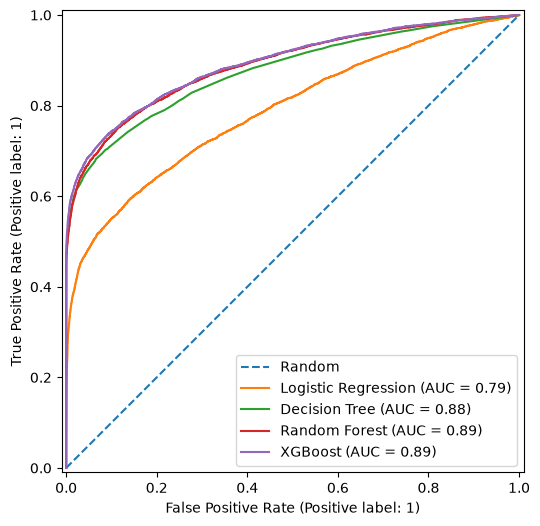

In [114]:
fix, ax = plt.subplots(figsize=(6,6))
ax.plot([0,1], [0,1], linestyle='--', label='Random')
RocCurveDisplay.from_predictions(y_val, y_val_pred_logreg, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_predictions(y_val, y_val_pred_dt, ax=ax, name='Decision Tree')
RocCurveDisplay.from_predictions(y_val, y_val_pred_rf, ax=ax, name='Random Forest')
RocCurveDisplay.from_predictions(y_val, y_val_pred_xgb, ax=ax, name='XGBoost')
plt.savefig('../reports/figures/roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


# Evaluating XGBoost on test

In [106]:
prediction_prob = final_xgb_model.predict_proba(X_test)[:, 1]
prediction = (prediction_prob >= 0.23).astype(int)

metrics = {
    "ROC-AUC": roc_auc_score(y_test, prediction_prob),
    "PR-AUC": average_precision_score(y_test, prediction_prob),
    "Precision": precision_score(y_test, prediction),
    "Recall": recall_score(y_test, prediction),
    "Accuracy": accuracy_score(y_test, prediction),
}

for name, score in metrics.items():
    print(f"{name:<10}: {score:.4f}")

ROC-AUC   : 0.8900
PR-AUC    : 0.8335
Precision : 0.7060
Recall    : 0.7349
Accuracy  : 0.8613


# Error Analysis